In [2]:
import random
import matplotlib.pyplot as plt
import numpy as np


In [3]:
POP_SIZE = 20
CHROM_LENGTH = 16
MUTATION_RATE = 0.01
GENERATIONS = 50

# Generate biased chromosome to start around fitness ~5
def random_chrom():
    s = ""
    for _ in range(CHROM_LENGTH):
        # ~30% chance of 1 → average fitness ~5
        s += "1" if random.random() < 0.30 else "0"
    return s

def fitness(chrom):
    return chrom.count("1")

def tournament(pop):
    a = random.choice(pop)
    b = random.choice(pop)
    return a if fitness(a) > fitness(b) else b

def crossover(p1, p2):
    point = random.randint(1, CHROM_LENGTH - 1)
    return p1[:point] + p2[point:], p2[:point] + p1[point:]

def mutate(chrom):
    chrom = list(chrom)
    for i in range(CHROM_LENGTH):
        if random.random() < MUTATION_RATE:
            chrom[i] = "1" if chrom[i] == "0" else "0"
    return "".join(chrom)


In [4]:
population = [random_chrom() for _ in range(POP_SIZE)]
best_history = []
avg_history = []

for gen in range(GENERATIONS):

    new_population = []

    while len(new_population) < POP_SIZE:
        p1 = tournament(population)
        p2 = tournament(population)

        c1, c2 = crossover(p1, p2)
        c1 = mutate(c1)
        c2 = mutate(c2)

        new_population.append(c1)
        if len(new_population) < POP_SIZE:
            new_population.append(c2)

    population = new_population

    # evaluate best & average fitness
    fits = [fitness(x) for x in population]
    best = max(fits)
    avg = sum(fits) / len(fits)

    best_history.append(best)
    avg_history.append(avg)

    print(f"Generation {gen+1:02d} | Best: {best} | Avg: {avg:.2f}")


Generation 01 | Best: 8 | Avg: 4.95
Generation 02 | Best: 10 | Avg: 5.65
Generation 03 | Best: 11 | Avg: 6.55
Generation 04 | Best: 10 | Avg: 7.55
Generation 05 | Best: 10 | Avg: 8.60
Generation 06 | Best: 11 | Avg: 9.00
Generation 07 | Best: 11 | Avg: 9.30
Generation 08 | Best: 11 | Avg: 9.85
Generation 09 | Best: 12 | Avg: 10.25
Generation 10 | Best: 12 | Avg: 10.65
Generation 11 | Best: 12 | Avg: 10.90
Generation 12 | Best: 13 | Avg: 11.50
Generation 13 | Best: 13 | Avg: 11.80
Generation 14 | Best: 13 | Avg: 12.10
Generation 15 | Best: 14 | Avg: 12.35
Generation 16 | Best: 14 | Avg: 12.80
Generation 17 | Best: 15 | Avg: 12.95
Generation 18 | Best: 15 | Avg: 13.20
Generation 19 | Best: 15 | Avg: 13.75
Generation 20 | Best: 15 | Avg: 14.15
Generation 21 | Best: 15 | Avg: 14.45
Generation 22 | Best: 16 | Avg: 14.65
Generation 23 | Best: 16 | Avg: 14.80
Generation 24 | Best: 16 | Avg: 15.20
Generation 25 | Best: 16 | Avg: 15.50
Generation 26 | Best: 16 | Avg: 15.60
Generation 27 | Best:

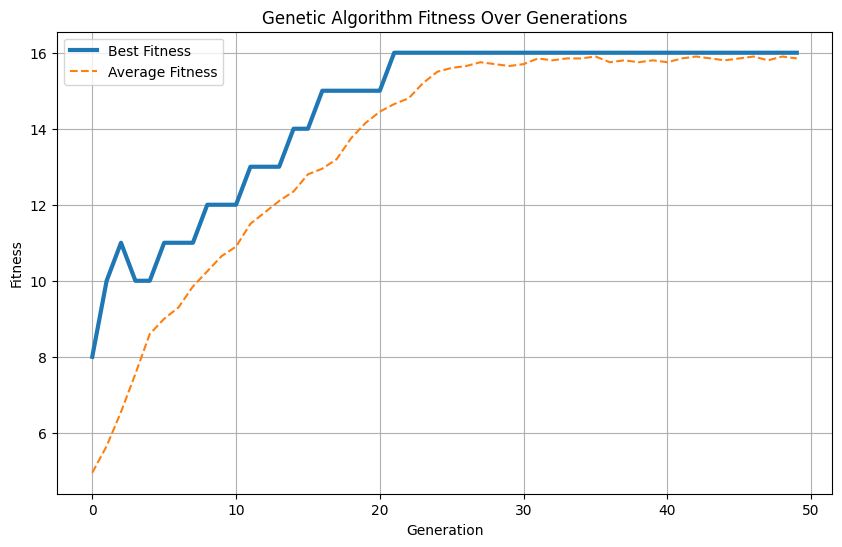

In [5]:
plt.figure(figsize=(10,6))
plt.plot(best_history, label="Best Fitness", linewidth=3)
plt.plot(avg_history, label="Average Fitness", linestyle="--")
plt.title("Genetic Algorithm Fitness Over Generations")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.grid(True)
plt.legend()
plt.show()


In [6]:
best_final_index = np.argmax(best_history)
print("Best fitness:", best_history[-1])
print("Final best chromosome:", population[np.argmax([fitness(c) for c in population])])


Best fitness: 16
Final best chromosome: 1111111111111111
